## Import libraries

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
import plotly.graph_objects as go
from collections import Counter
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout
from keras.utils import to_categorical
from imblearn.over_sampling import SMOTE

#### Load Dataset

In [60]:
df = pd.read_csv('UpdatedResumeDataSet.csv')

In [61]:
print("Data Shape:", df.shape)
print("\nCategory Value Counts:\n", df['Category'].value_counts())

Data Shape: (962, 2)

Category Value Counts:
 Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Sales                        40
Data Science                 40
Mechanical Engineer          40
ETL Developer                40
Blockchain                   40
Operations Manager           40
Arts                         36
Database                     33
Health and fitness           30
PMO                          30
Electrical Engineering       30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64


## Data Analysis & Visualization

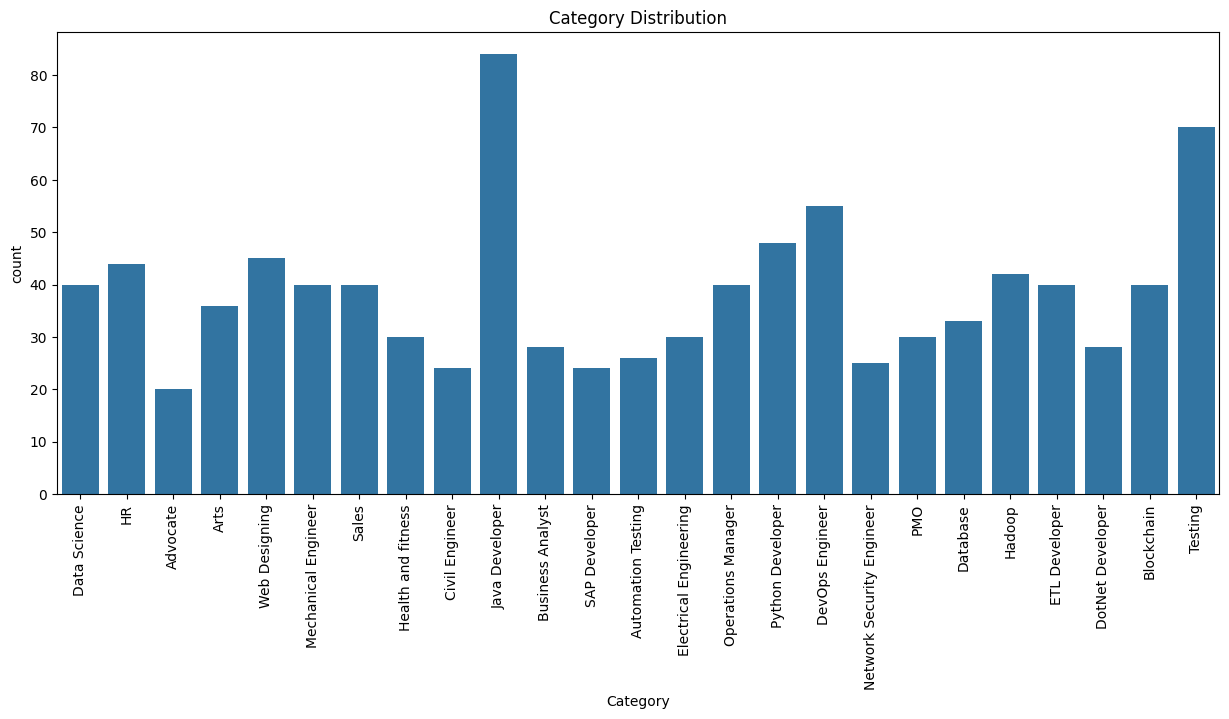

In [62]:
# Visualize the distribution of categories
plt.figure(figsize=(15, 6))
sns.countplot(x=df['Category'])
plt.xticks(rotation=90)
plt.title('Category Distribution')
plt.show()

In [63]:
# Pie Chart
counts = df['Category'].value_counts()
labels = df['Category'].unique()
fig = go.Figure(data=[go.Pie(labels=labels, values=counts)])
fig.update_layout(title='Resume Categories')
fig.show()

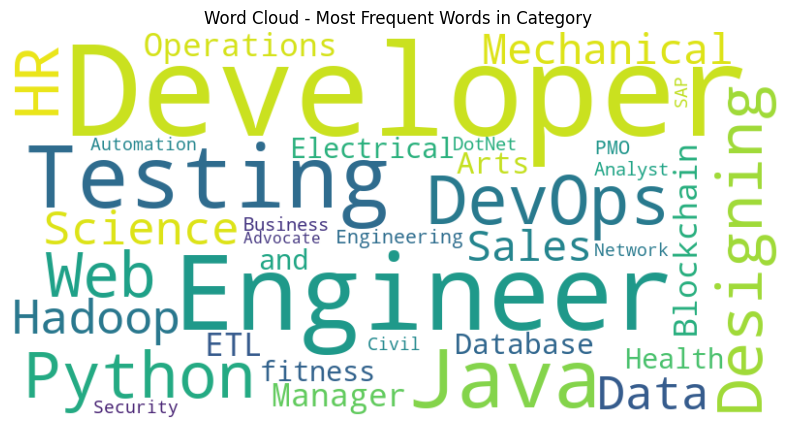

In [64]:

# Combine text from Category columns
combined_text = ' '.join(df['Category'])

# Tokenize and count word frequency
word_counts = Counter(combined_text.split())

# Create a word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Most Frequent Words in Category')
plt.show()

In [65]:
df['Resume'][0]

'Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details \r\n\r\nData Science Assurance Associate \r\n\r\nData Science Assurance Associate - Ernst & Young LLP\r\nSkill Details \r\nJAVASCRIPT- Exprience - 24 months\r\njQuery- Exprience - 24 months\r\nPython- Exprience - 24 monthsCompany Details \r\ncompany - Ernst & Young LLP\r\ndescription - Fraud Investigatio

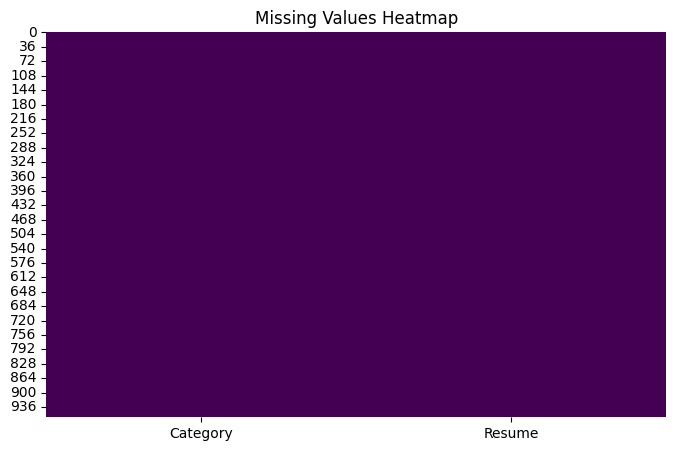

In [66]:
# Missing values check
plt.figure(figsize=(8, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [67]:
df.isnull().sum()

Category    0
Resume      0
dtype: int64

In [68]:
def resume_cleaning(text):
    # Remove HTML tags 
    cleaned_text = re.sub(r'<.*?>', ' ', text)
    # Remove non-english characters, punctuation, digits, extra whitespace
    cleaned_text = re.sub('[^a-zA-Z]', ' ', cleaned_text)
    cleaned_text = re.sub(r'[^\w\s]|_', ' ', cleaned_text)
    cleaned_text = re.sub(r'\d+', ' ', cleaned_text)
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()
    cleaned_text = re.sub('http\S+\s', " ", cleaned_text)
    
    # Convert to lowercase
    cleaned_text = cleaned_text.lower()
    
    # Tokenize and remove stopwords
    words = word_tokenize(cleaned_text)
    stop_words = set(stopwords.words('english'))
    filtered_words = [word for word in words if word not in stop_words]
    
    # Apply stemming
    stemmer = PorterStemmer()
    stemmed_words = [stemmer.stem(word) for word in filtered_words]
    
    return ' '.join(stemmed_words)


In [69]:
# applying text cleaning function in my dataset
df['Cleaned_Resume'] = df['Resume'].apply(lambda x: resume_cleaning(x))


## Preprocessing and Encoding

In [70]:
# LABEL ENCODING
encoder = LabelEncoder()
df['Category'] = encoder.fit_transform(df['Category'])
num_classes = len(encoder.classes_)

### Data Splitting

In [71]:
# TRAIN-TEST SPLIT
X_train, X_valid, y_train, y_valid = train_test_split(
    df['Cleaned_Resume'], 
    df['Category'], 
    test_size=0.15, 
    random_state=42, 
    stratify=df['Category'] # Stratify ensures consistent class distribution
)

print("\nTrain data size:", X_train.shape)
print("Validation data size:", X_valid.shape)


Train data size: (817,)
Validation data size: (145,)


### Vectorization of TF-IDF

In [72]:
tfidf = TfidfVectorizer(stop_words='english', max_features=1000, ngram_range=(1, 2))

# Fit only on training data, transform both
tfidf_train_vectors = tfidf.fit_transform(X_train)
tfidf_valid_vectors = tfidf.transform(X_valid)

tfidf_train_arrays = tfidf_train_vectors.toarray()
tfidf_valid_arrays = tfidf_valid_vectors.toarray()

In [73]:

#  BALANCE DATA WITH SMOTE (Training Data Only)

print("Applying SMOTE to training data...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(tfidf_train_arrays, y_train)

# Convert labels to categorical (one-hot encoding)
y_train_smote_label = to_categorical(y_train_smote, num_classes=num_classes)
y_valid_label = to_categorical(y_valid, num_classes=num_classes)

Applying SMOTE to training data...


#### NEURAL NETWORK MODEL

In [74]:
model = Sequential()
model.add(Dense(512, input_dim=tfidf_train_arrays.shape[1], activation='relu'))
model.add(Dropout(0.5)) 
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3)) 
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy', 
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), 
              metrics=['accuracy'])

# Early Stopping
early_stopper = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',         
    patience=3,                 
    restore_best_weights=True   
)

# Train the model
print("\nStarting Model Training...")
history = model.fit(
    X_train_smote, 
    y_train_smote_label,
    epochs=50,                  
    batch_size=32, 
    validation_data=(tfidf_valid_arrays, y_valid_label),
    callbacks=[early_stopper]
)





Starting Model Training...
Epoch 1/50


C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3177 - loss: 3.0789 - val_accuracy: 0.7862 - val_loss: 2.6864
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7628 - loss: 1.7160 - val_accuracy: 0.9862 - val_loss: 0.5400
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9685 - loss: 0.3218 - val_accuracy: 0.9931 - val_loss: 0.1051
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9944 - loss: 0.0921 - val_accuracy: 0.9931 - val_loss: 0.0519
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9961 - loss: 0.0546 - val_accuracy: 0.9931 - val_loss: 0.0346
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9977 - loss: 0.0307 - val_accuracy: 0.9931 - val_loss: 0.0279
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9972 - loss: 0.0225 - val_accuracy: 0.9931 - val_loss: 0.0278
Epoch 8/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9994 - loss: 0.0138 - val_accuracy: 0.9931 - val_loss: 0.0286
Ep

In [29]:
loss, accuracy = model.evaluate(tfidf_valid_arrays, y_valid_label, verbose=0)

y_val_pred_probs = model.predict(tfidf_valid_arrays)
y_val_pred = y_val_pred_probs.argmax(axis=1)

# Calculate explicit metrics (Macro average treats all classes equally)
precision, recall, f1, _ = precision_recall_fscore_support(y_valid, y_val_pred, average='macro')

print(f"\n--- Model Performance ---")
print(f"Final Validation Loss     : {loss:.4f}")
print(f"Final Validation Accuracy : {accuracy:.4f}")
print(f"Macro Precision           : {precision:.4f}")
print(f"Macro Recall              : {recall:.4f}")
print(f"Macro F1 Score            : {f1:.4f}")
print("-" * 25)

print("\nClassification Report:")
class_names = encoder.inverse_transform(range(num_classes))
print(classification_report(y_valid, y_val_pred, target_names=class_names))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

--- Model Performance ---
Final Validation Loss     : 0.0256
Final Validation Accuracy : 0.9931
Macro Precision           : 0.9920
Macro Recall              : 0.9950
Macro F1 Score            : 0.9929
-------------------------

Classification Report:
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         3
                     Arts       1.00      1.00      1.00         5
       Automation Testing       0.80      1.00      0.89         4
               Blockchain       1.00      1.00      1.00         6
         Business Analyst       1.00      1.00      1.00         4
           Civil Engineer       1.00      1.00      1.00         4
             Data Science       1.00      1.00      1.00         6
                 Database       1.00      1.00      1.00         5
          DevOps Engineer       1.00      0.88      0.93         8
         DotNet Developer       1.00   

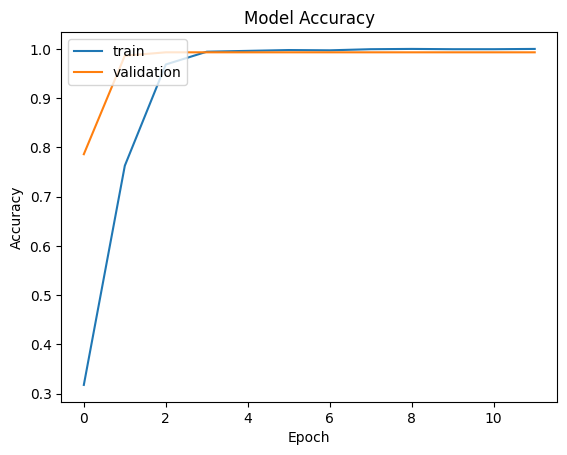

In [76]:
# Plot training history
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

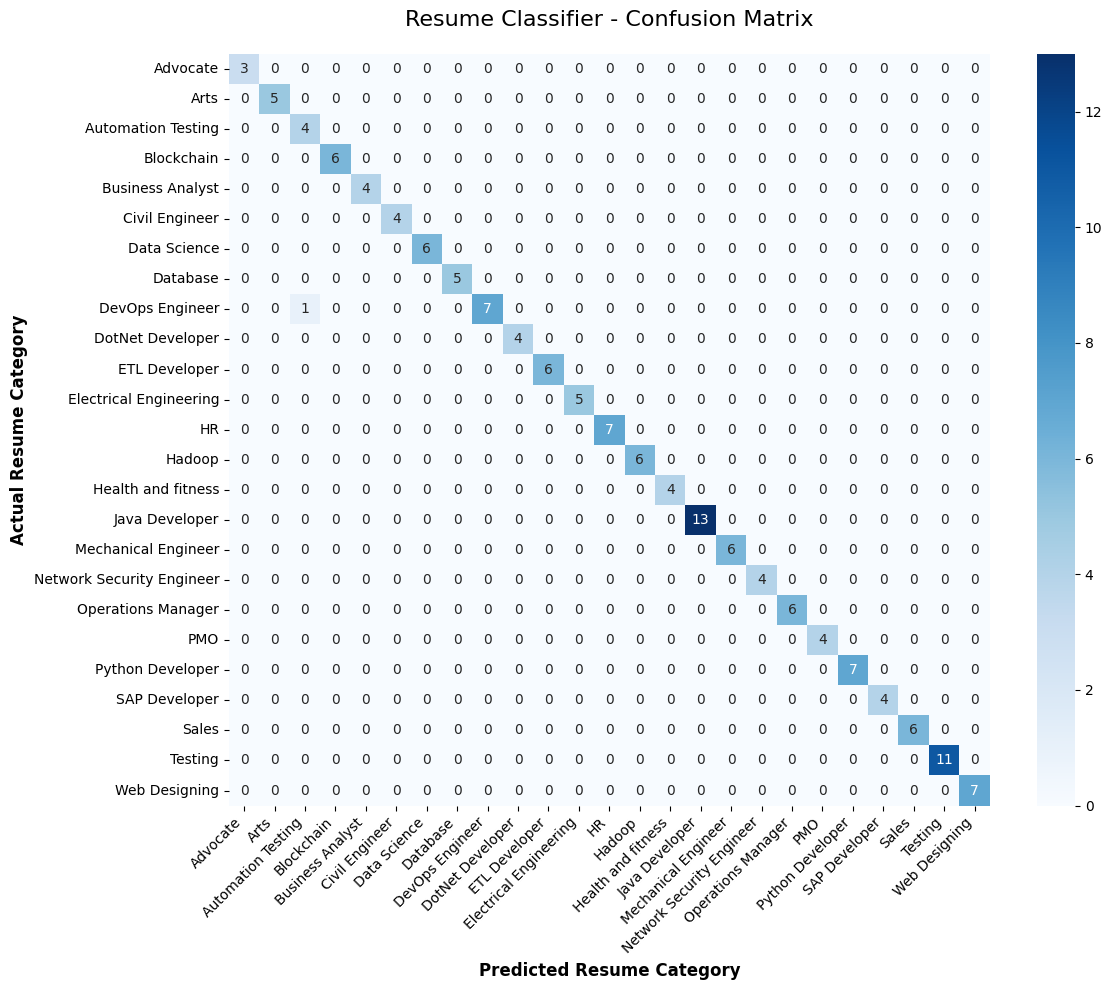

In [77]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_valid, y_val_pred)
plt.figure(figsize=(12, 10)) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Resume Classifier - Confusion Matrix', fontsize=16, pad=20)
plt.ylabel('Actual Resume Category', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Resume Category', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right') 
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Save Model Preprocessors

In [31]:
model.save('my_text_classifier.keras')
joblib.dump(encoder, 'label_encoder.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl') 
print("\nFiles saved successfully: Model, Encoder, Vectorizer.")


Files saved successfully: Model, Encoder, Vectorizer.


#### INFERENCE FUNCTION (Prediction)

In [32]:
def pred(resume_text):
    print("\nProcessing unseen resume...")
    
    # 1. MUST clean the unseen text exactly how we cleaned training data
    cleaned_resume = resume_cleaning(resume_text)
    
    # 2. Put it in a list format for the vectorizer
    text_list = [cleaned_resume]
    
    # 3. Vectorize
    tfidf_features = tfidf.transform(text_list)
    if hasattr(tfidf_features, "toarray"):
        tfidf_features = tfidf_features.toarray()
        
    # 4. Predict
    prediction_probs = model.predict(tfidf_features, verbose=0)
    predicted_index = prediction_probs.argmax(axis=1)
    
    # 5. Decode label
    predicted_category = encoder.inverse_transform(predicted_index)[0]
    confidence = prediction_probs[0][predicted_index[0]] * 100
    
    THRESHOLD = 65.0 
    
    print("-" * 30)
    if confidence >= THRESHOLD:
        print(f"Predicted Category : {predicted_category}")
        print(f"Confidence Score   : {confidence:.2f}%")
    else:
        print(f"Predicted Category : Unknown / Unrecognized Field")
        print(f"Confidence Score   : {confidence:.2f}% (Below {THRESHOLD}% threshold)")
        predicted_category = "Unknown" 
    print("-" * 30)
    
    return predicted_category

In [78]:
myresume = """
Michael Rodriguez is a results-driven Civil Engineer with over 8 years of experience in the design, planning, and management of large-scale infrastructure projects. He specializes in structural engineering, site development, and transportation systems. Michael has a strong track record of ensuring projects are completed on time, within budget, and in strict compliance with safety and environmental regulations.

He is highly proficient in utilizing industry-standard software to perform structural analysis, create detailed blueprints, and model complex terrain. Michael excels in coordinating with architects, contractors, and local government agencies to resolve on-site engineering challenges and optimize construction materials like reinforced concrete and structural steel.

Key Skills:
- Structural Analysis and Design
- AutoCAD Civil 3D, SAP2000, and Revit
- Geotechnical Engineering and Soil Testing
- Project Management and Cost Estimation
- Highway and Transportation Design
- Hydrology and Drainage Systems
- Surveying and Topographical Mapping
- Construction Materials (Concrete/Steel)
- Environmental Compliance and OSHA Regulations
- Site Inspection and Quality Control

Certifications and Licenses:
- Professional Engineer (PE) License
- LEED Accredited Professional (LEED AP)

Education:
B.S. in Civil Engineering, State University of Technology, 2011-2015

Professional Experience:
- Senior Project Engineer at Horizon Construction Group (2018-Present)
  * Led the structural design and site grading for a $45M commercial development.
  * Conducted load-bearing analysis for concrete foundations and steel frameworks.
- Junior Civil Engineer at CityWorks Urban Planning (2015-2018)
  * Designed storm-water drainage systems to mitigate flood risks in urban zones.
  * Assisted in surveying land and preparing environmental impact reports.

Languages:
- English (Fluent)
- Spanish (Native)
"""

# Now, test the model with the Civil Engineer-focused resume
pred(myresume)


Processing unseen resume...
------------------------------
Predicted Category : Civil Engineer
Confidence Score   : 99.90%
------------------------------


'Civil Engineer'

In [79]:

myresume = """I am a data scientist specializing in machine
learning, deep learning, and computer vision. With
a strong background in mathematics, statistics,
and programming, I am passionate about
uncovering hidden patterns and insights in data.
I have extensive experience in developing
predictive models, implementing deep learning
algorithms, and designing computer vision
systems. My technical skills include proficiency in
Python, Sklearn, TensorFlow, and PyTorch.
What sets me apart is my ability to effectively
communicate complex concepts to diverse
audiences. I excel in translating technical insights
into actionable recommendations that drive
informed decision-making.
If you're looking for a dedicated and versatile data
scientist to collaborate on impactful projects, I am
eager to contribute my expertise. Let's harness the
power of data together to unlock new possibilities
and shape a better future.
Contact & Sources
Email: 611noorsaeed@gmail.com
Phone: 03442826192
Github: https://github.com/611noorsaeed
Linkdin: https://www.linkedin.com/in/noor-saeed654a23263/
Blogs: https://medium.com/@611noorsaeed
Youtube: Artificial Intelligence
ABOUT ME
WORK EXPERIENCE
SKILLES
NOOR SAEED
LANGUAGES
English
Urdu
Hindi
I am a versatile data scientist with expertise in a wide
range of projects, including machine learning,
recommendation systems, deep learning, and computer
vision. Throughout my career, I have successfully
developed and deployed various machine learning models
to solve complex problems and drive data-driven
decision-making
Machine Learnine
Deep Learning
Computer Vision
Recommendation Systems
Data Visualization
Programming Languages (Python, SQL)
Data Preprocessing and Feature Engineering
Model Evaluation and Deployment
Statistical Analysis
Communication and Collaboration
"""

# Call the function
pred(myresume)


Processing unseen resume...
------------------------------
Predicted Category : Data Science
Confidence Score   : 99.79%
------------------------------


'Data Science'

In [80]:
myresume = """
David Chen is a detail-oriented and innovative Electrical Engineer with 6 years of experience in designing, developing, and testing electrical systems and components. He specializes in power distribution, control systems, and renewable energy integration. David has a proven track record of managing projects from concept through to manufacturing, ensuring compliance with industry standards and safety regulations.

He possesses strong analytical skills and hands-on experience with circuit design, PCB layout, and PLC programming. David is adept at collaborating with cross-functional engineering teams to troubleshoot complex electrical issues and optimize system performance, reducing operational costs and improving energy efficiency.

Key Skills:
- Power Systems and Distribution
- Circuit Design and PCB Layout
- PLC Programming (Allen-Bradley, Siemens)
- AutoCAD Electrical and SolidWorks
- MATLAB and Simulink
- Renewable Energy Systems (Solar/Wind integration)
- Microcontroller Programming (C/C++)
- Testing and Troubleshooting
- Project Management
- National Electrical Code (NEC) Compliance

Certifications and Licenses:
- Professional Engineer (PE) License
- Certified Automation Professional (CAP)

Education:
B.S. in Electrical Engineering, Tech Institute of Engineering, 2014-2018

Professional Experience:
- Electrical Engineer at Apex Energy Solutions (2020-Present)
  * Designed and implemented low and medium voltage power distribution systems.
  * Programmed PLCs for automated manufacturing lines, increasing output by 15%.
- Junior Electrical Engineer at Spark Dynamics (2018-2020)
  * Assisted in the design of custom PCBs for consumer electronics.
  * Conducted rigorous testing and validation of prototype circuits.

Languages:
- English (Fluent)
- Mandarin (Conversational)
"""

# Now, test the model with the Electrical Engineer-focused resume
pred(myresume)


Processing unseen resume...
------------------------------
Predicted Category : Electrical Engineering
Confidence Score   : 99.08%
------------------------------


'Electrical Engineering'